# Data Curation with RDKit

Pipeline:
1. Load the KNIME CSV
2. Parse SMILES with RDKit
3. Remove salts (keep largest organic fragment)
4. Add hydrogens
5. Neutralise formal charges
6. Standardise molecules (normalise functional groups, tautomer consistency)
7. Filter out inorganic compounds
8. Save curated data

In [57]:
import pandas as pd
import numpy as np
from rdkit import Chem
from rdkit.Chem import MolStandardize
from rdkit.Chem.MolStandardize import rdMolStandardize
from rdkit.Chem.rdMolDescriptors import CalcMolFormula

---
## 1. Load data

In [ ]:
# df = pd.read_csv('./data/dataset_final_imane_original.csv')
df = pd.read_csv('./data/the_final_data_base_in_KNIME.csv')
print(f'Rows loaded: {len(df)}')
df[['CAS_str', 'Chemical_name', 'SMILES']].head()

Rows loaded: 2375


,CAS_str,Chemical_name,SMILES
0,50-06-6,Phenobarbital,CCC1(C(=O)NC(=O)NC1=O)C2=CC=CC=C2
1,50-18-0,Cyclophosphamide,C1CNP(=O)(OC1)N(CCCl)CCCl
2,50-28-2,17beta-Estradiol,C[C@]12CC[C@H]3[C@H]([C@@H]1CC[C@@H]2O)CCC4=C3...
3,50-29-3,"p,p'-DDT",C1=CC(=CC=C1C(C2=CC=C(C=C2)Cl)C(Cl)(Cl)Cl)Cl
4,50-30-6,"2,6-Dichlorobenzoic acid",C1=CC(=C(C(=C1)Cl)C(=O)O)Cl


In [59]:
df.tail()

,CAS_str,Chemical_name,log_LC50,n_measurements,SMILES,mlecule_H_final,SlogP,SMR,LabuteASA,TPSA,...,MQN33,MQN34,MQN35,MQN36,MQN37,MQN38,MQN39,MQN40,MQN41,MQN42
2370,1197379-16-0,"4-(1-Ethyl-1,3-dimethylpentyl)-2-nitrophenol",1.007160,3,CCC(C)CC(C)(CC)C1=CC(=C(C=C1)O)[N+](=O)[O-],[H]Oc1c([H])c([H])c(C(C([H])([H])[H])(C([H])([...,4.4043,76.4762,146.564083,63.37,...,0,0,0,1,0,0,0,0,0,0
2371,1197379-18-2,"2-Bromo-4-(1-ethyl-1,3-dimethylpentyl)phenol",1.207767,3,CCC(C)CC(C)(CC)C1=CC(=C(C=C1)O)Br,[H]Oc1c([H])c([H])c(C(C([H])([H])[H])(C([H])([...,5.2586,77.5218,145.778655,20.23,...,0,0,0,1,0,0,0,0,0,0
2372,Metalgrp.CrIII,Chromium chloride (CrCl3),1.423755,35,Cl[Cr](Cl)Cl,Cl[Cr](Cl)Cl,2.0660,17.5590,41.650842,0.00,...,0,0,0,0,0,0,0,0,0,0
2373,Metalgrp.Hg,Mercuric chloride,-0.628983,255,Cl[Hg]Cl,Cl[Hg]Cl,1.3765,11.7060,38.427142,0.00,...,0,0,0,0,0,0,0,0,0,0
2374,Metalgrp.V,Vanadium pentoxide,0.834391,105,O=[V](=O)O[V](=O)=O,O=[V](=O)O[V](=O)=O,-0.5486,3.8310,48.380954,77.51,...,0,0,0,0,0,0,0,0,0,0


## For Imane 

In [60]:
# For Imane , Abdel has to comment this line to avoid deleting the meta data
df = df[~df["CAS_str"].str.contains("Meta", case=False, na=False)]

In [61]:
df.tail()

,CAS_str,Chemical_name,log_LC50,n_measurements,SMILES,mlecule_H_final,SlogP,SMR,LabuteASA,TPSA,...,MQN33,MQN34,MQN35,MQN36,MQN37,MQN38,MQN39,MQN40,MQN41,MQN42
2367,874967-67-6,Sedaxane,-0.170091,4,CN1C=C(C(=N1)C(F)F)C(=O)NC2=CC=CC=C2C3CC3C4CC4,[H]c1c([H])c([H])c(C2([H])C([H])([H])C2([H])C2...,4.12350,86.1322,165.163499,46.92,...,2,0,1,1,0,0,0,0,0,0
2368,907204-31-3,Fluxapyroxad,0.380211,1,CN1C=C(C(=N1)C(F)F)C(=O)NC2=CC=CC=C2C3=CC(=C(C...,[H]c1c([H])c([H])c(N([H])C(=O)c2c(C([H])(F)F)n...,4.69430,87.8702,166.704415,46.92,...,0,0,1,2,0,0,0,0,0,0
2369,950782-86-2,Indaziflam,-0.283654,3,C[C@H]1CC2=C([C@@H]1NC3=NC(=NC(=N3)N)C(C)F)C=C...,[H]c1c([H])c2c(c([H])c1C([H])([H])[H])[C@]([H]...,3.13812,84.1731,157.025073,76.72,...,0,0,1,2,0,0,0,0,2,1
2370,1197379-16-0,"4-(1-Ethyl-1,3-dimethylpentyl)-2-nitrophenol",1.007160,3,CCC(C)CC(C)(CC)C1=CC(=C(C=C1)O)[N+](=O)[O-],[H]Oc1c([H])c([H])c(C(C([H])([H])[H])(C([H])([...,4.40430,76.4762,146.564083,63.37,...,0,0,0,1,0,0,0,0,0,0
2371,1197379-18-2,"2-Bromo-4-(1-ethyl-1,3-dimethylpentyl)phenol",1.207767,3,CCC(C)CC(C)(CC)C1=CC(=C(C=C1)O)Br,[H]Oc1c([H])c([H])c(C(C([H])([H])[H])(C([H])([...,5.25860,77.5218,145.778655,20.23,...,0,0,0,1,0,0,0,0,0,0


In [62]:
# Check for missing SMILES
print(f'Missing SMILES: {df["SMILES"].isna().sum()}')
df = df.dropna(subset=['SMILES']).reset_index(drop=True)
print(f'Rows after dropping missing SMILES: {len(df)}')

Missing SMILES: 0
Rows after dropping missing SMILES: 2372


---
## 2. Parse SMILES with RDKit

In [63]:
def parse_smiles(smiles):
    try:
        mol = Chem.MolFromSmiles(smiles)
        return mol
    except:
        return None

df['mol'] = df['SMILES'].apply(parse_smiles)

n_valid = df['mol'].notna().sum()
n_fail = df['mol'].isna().sum()
print(f'Valid molecules: {n_valid}')
print(f'Unparseable SMILES: {n_fail}')

df = df.dropna(subset=['mol']).reset_index(drop=True)

Valid molecules: 2372
Unparseable SMILES: 0


[18:43:34] WARNING: not removing hydrogen atom without neighbors
/var/folders/wc/y79sy_bd62b05zwn7tgfb2s40000gq/T/ipykernel_51274/3540612574.py:8: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['mol'] = df['SMILES'].apply(parse_smiles)


---
## 3. Remove salts (keep largest fragment)

In [64]:
def remove_salt(mol):
    frags = Chem.GetMolFrags(mol, asMols=True, sanitizeFrags=False)
    if len(frags) == 1:
        return mol
    largest = max(frags, key=lambda m: m.GetNumAtoms())
    try:
        Chem.SanitizeMol(largest)
        return largest
    except:
        return mol

n_before = df['mol'].apply(lambda m: len(Chem.GetMolFrags(m)) > 1).sum()
df['mol'] = df['mol'].apply(remove_salt)
print(f'Molecules with multiple fragments (salts) removed: {n_before}')
still_multi = df['mol'].apply(lambda m: len(Chem.GetMolFrags(m)) > 1).sum()
print(f'Still multi-fragment after clean: {still_multi}')

Molecules with multiple fragments (salts) removed: 330
Still multi-fragment after clean: 0


---
## 4. Add hydrogens

In [65]:
# df['mol'] = df['mol'].apply(Chem.AddHs)
# print('Added explicit hydrogens to all molecules')

---
## 5. Neutralise formal charges

In [66]:
def uncharger(mol):
    try:
        return rdMolStandardize.Uncharger().uncharge(mol)
    except:
        return mol

n_charged_before = sum(1 for m in df['mol'] if any(at.GetFormalCharge() != 0 for at in m.GetAtoms()))
df['mol'] = df['mol'].apply(uncharger)
n_charged_after = sum(1 for m in df['mol'] if any(at.GetFormalCharge() != 0 for at in m.GetAtoms()))
print(f'Molecules with formal charges before: {n_charged_before}')
print(f'Molecules with formal charges after:  {n_charged_after}')

[18:43:34] Running Uncharger
[18:43:34] Running Uncharger
[18:43:34] Running Uncharger
[18:43:34] Running Uncharger
[18:43:34] Running Uncharger
[18:43:34] Running Uncharger
[18:43:34] Running Uncharger
[18:43:34] Running Uncharger
[18:43:34] Running Uncharger
[18:43:34] Running Uncharger
[18:43:34] Running Uncharger
[18:43:34] Running Uncharger
[18:43:34] Running Uncharger
[18:43:34] Running Uncharger
[18:43:34] Running Uncharger
[18:43:34] Running Uncharger
[18:43:34] Running Uncharger
[18:43:34] Running Uncharger
[18:43:34] Running Uncharger
[18:43:34] Running Uncharger
[18:43:34] Running Uncharger
[18:43:34] Running Uncharger
[18:43:34] Running Uncharger
[18:43:34] Running Uncharger
[18:43:34] Removed negative charge.
[18:43:34] Running Uncharger
[18:43:34] Removed negative charge.
[18:43:34] Running Uncharger
[18:43:34] Running Uncharger
[18:43:34] Running Uncharger
[18:43:34] Running Uncharger
[18:43:34] Running Uncharger
[18:43:34] Running Uncharger
[18:43:34] Running Uncharger


Molecules with formal charges before: 422
Molecules with formal charges after:  245


[18:43:35] Running Uncharger
[18:43:35] Removed negative charge.
[18:43:35] Removed negative charge.
[18:43:35] Running Uncharger
[18:43:35] Removed negative charge.
[18:43:35] Removed negative charge.
[18:43:35] Running Uncharger
[18:43:35] Running Uncharger
[18:43:35] Running Uncharger
[18:43:35] Running Uncharger
[18:43:35] Running Uncharger
[18:43:35] Running Uncharger
[18:43:35] Removed negative charge.
[18:43:35] Running Uncharger
[18:43:35] Running Uncharger
[18:43:35] Running Uncharger
[18:43:35] Removed negative charge.
[18:43:35] Running Uncharger
[18:43:35] Running Uncharger
[18:43:35] Running Uncharger
[18:43:35] Running Uncharger
[18:43:35] Running Uncharger
[18:43:35] Running Uncharger
[18:43:35] Running Uncharger
[18:43:35] Running Uncharger
[18:43:35] Removed negative charge.
[18:43:35] Running Uncharger
[18:43:35] Removed negative charge.
[18:43:35] Running Uncharger
[18:43:35] Running Uncharger
[18:43:35] Running Uncharger
[18:43:35] Running Uncharger
[18:43:35] Runni

---
## 6. Standardise molecules

Normalise functional groups and canonicalise tautomers using RDKit's `rdMolStandardize`.

In [67]:
normalizer = rdMolStandardize.Normalizer()
tautomerizer = rdMolStandardize.TautomerEnumerator()

def standardize(mol):
    try:
        mol = normalizer.normalize(mol)
        mol = tautomerizer.Canonicalize(mol)
        return mol
    except:
        return mol

df['mol'] = df['mol'].apply(standardize)
print('Standardisation complete (normalisation + tautomer canonicalisation).')

[18:43:35] Initializing Normalizer
[18:43:35] Running Normalizer
[18:43:35] Running Normalizer
[18:43:35] Running Normalizer
[18:43:35] Running Normalizer
[18:43:35] Running Normalizer
[18:43:35] Running Normalizer
[18:43:35] Running Normalizer
[18:43:35] Running Normalizer
[18:43:35] Running Normalizer
[18:43:35] Running Normalizer
[18:43:35] Running Normalizer
[18:43:35] Running Normalizer
[18:43:35] Running Normalizer
[18:43:35] Running Normalizer
[18:43:35] Running Normalizer
[18:43:35] Can't kekulize mol.  Unkekulized atoms: 4 8
[18:43:35] Running Normalizer
[18:43:35] Running Normalizer
[18:43:35] Running Normalizer
[18:43:35] Running Normalizer
[18:43:35] Running Normalizer
[18:43:35] Running Normalizer
[18:43:35] Running Normalizer
[18:43:35] Running Normalizer
[18:43:35] Running Normalizer
[18:43:35] Running Normalizer
[18:43:35] Running Normalizer
[18:43:35] Running Normalizer
[18:43:35] Running Normalizer
[18:43:35] Running Normalizer
[18:43:35] Running Normalizer
[18:43:35]

Standardisation complete (normalisation + tautomer canonicalisation).


[18:43:45] Running Normalizer
[18:43:45] Running Normalizer
[18:43:45] Running Normalizer
[18:43:45] Running Normalizer
[18:43:45] Running Normalizer
[18:43:45] Running Normalizer
[18:43:45] Running Normalizer
[18:43:45] Running Normalizer
[18:43:45] Running Normalizer
[18:43:45] Running Normalizer
[18:43:45] Running Normalizer
[18:43:45] Running Normalizer
[18:43:45] Running Normalizer
[18:43:45] Running Normalizer
[18:43:45] Running Normalizer
[18:43:45] Running Normalizer
[18:43:45] Running Normalizer
[18:43:45] Running Normalizer
[18:43:45] Running Normalizer
[18:43:45] Running Normalizer
[18:43:45] Running Normalizer
[18:43:45] Running Normalizer
[18:43:45] Running Normalizer
[18:43:45] Running Normalizer
[18:43:45] Running Normalizer
[18:43:45] Running Normalizer
[18:43:45] Running Normalizer
[18:43:45] Running Normalizer
[18:43:45] Running Normalizer
[18:43:45] Running Normalizer
[18:43:45] Running Normalizer
[18:43:45] Running Normalizer
[18:43:45] Running Normalizer
[18:43:45]

---
## 7. Filter out inorganic compounds

Definition: a molecule is **inorganic** if it:
- Contains **no carbon atoms**, OR
- Contains **heavy atoms outside the organic set** (e.g. metals)

Both filters are shown below.

In [68]:
# ---- Filter definitions ----

organic_set = {'H', 'B', 'C', 'N', 'O', 'F', 'Si', 'P', 'S', 'Cl', 'Se', 'Br', 'I'}

def has_carbon(mol):
    return any(at.GetAtomicNum() == 6 for at in mol.GetAtoms())

def is_inorganic_no_carbon(mol):
    """Flag molecules with zero carbon atoms."""
    return not has_carbon(mol)

def is_inorganic_heavy(mol):
    """Flag molecules with atoms outside the organic set (e.g. metals)."""
    for at in mol.GetAtoms():
        if at.GetSymbol() not in organic_set:
            return True
    return False

# ---- Apply filters ----

df['inorganic_no_carbon'] = df['mol'].apply(is_inorganic_no_carbon)
df['inorganic_heavy_atom'] = df['mol'].apply(is_inorganic_heavy)
df['inorganic'] = df['inorganic_no_carbon'] | df['inorganic_heavy_atom']

n_inorganic = df['inorganic'].sum()
print('=== INORGANIC FILTER RESULTS ===')
print(f'Filter 1 - No carbon:               {df["inorganic_no_carbon"].sum()}')
print(f'Filter 2 - Non-organic heavy atom:   {df["inorganic_heavy_atom"].sum()}')
print(f'Total flagged as inorganic:           {n_inorganic}')
print(f'Organic molecules retained:            {len(df) - n_inorganic}')

=== INORGANIC FILTER RESULTS ===
Filter 1 - No carbon:               22
Filter 2 - Non-organic heavy atom:   55
Total flagged as inorganic:           69
Organic molecules retained:            2303


/var/folders/wc/y79sy_bd62b05zwn7tgfb2s40000gq/T/ipykernel_51274/3549395085.py:21: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['inorganic_no_carbon'] = df['mol'].apply(is_inorganic_no_carbon)
/var/folders/wc/y79sy_bd62b05zwn7tgfb2s40000gq/T/ipykernel_51274/3549395085.py:22: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['inorganic_heavy_atom'] = df['mol'].apply(is_inorganic_heavy)
/var/folders/wc/y79sy_bd62b05zwn7tgfb2s40000gq/T/ipykernel_51274/3549395085.py:23: PerformanceWarning: DataFrame is highly fragmented.  This is

In [69]:
# ---- Display flagged molecules ----

inorganic_df = df[df['inorganic']][['CAS_str', 'Chemical_name', 'SMILES']].copy()

print(f'--- {len(inorganic_df)} molecules flagged as inorganic ---')
if len(inorganic_df) > 0:
    formula_map = dict(zip(range(len(df)), (CalcMolFormula(m) for m in df['mol'])))
    inorganic_df = inorganic_df.copy()
    inorganic_df['Formula'] = [formula_map[i] for i in df[df['inorganic']].index]
    display(inorganic_df)
else:
    print('No inorganic molecules found.')

--- 69 molecules flagged as inorganic ---


,CAS_str,Chemical_name,SMILES,Formula
24,54-64-8,Thimerosal,CC[Hg]SC1=CC=CC=C1C(=O)[O-].[Na+],C9H10HgO2S
33,56-35-9,Bis(tributyltin)oxide,CCCC[Sn](CCCC)(CCCC)O[Sn](CCCC)(CCCC)CCCC,C24H54OSn2
34,56-36-0,Tributyltin acetate,CCCC[Sn](CCCC)(CCCC)OC(=O)C,C14H30O2Sn
68,62-38-4,Phenylmercuric acetate,CC(=O)O[Hg]C1=CC=CC=C1,C8H8HgO2
104,75-60-5,Dimethylarsinic acid,C[As](=O)(C)O,C2H7AsO2
...,...,...,...,...
1739,13863-41-7,Bromine chloride,ClBr,BrCl
1749,14275-57-1,Tributyltin maleate (2:1),CCCC[Sn](CCCC)(CCCC)OC(=O)/C=C\C(=O)O[Sn](CCCC...,C28H56O4Sn2
1764,14986-84-6,Hexasodium tetraphosphate,[O-]P(=O)([O-])OP(=O)([O-])OP(=O)([O-])OP(=O)(...,H6O13P4
1797,16903-35-8,Tetrachloroauric acid,[H+].[Cl-].[Cl-].[Cl-].[Cl-].[Au+3],H+


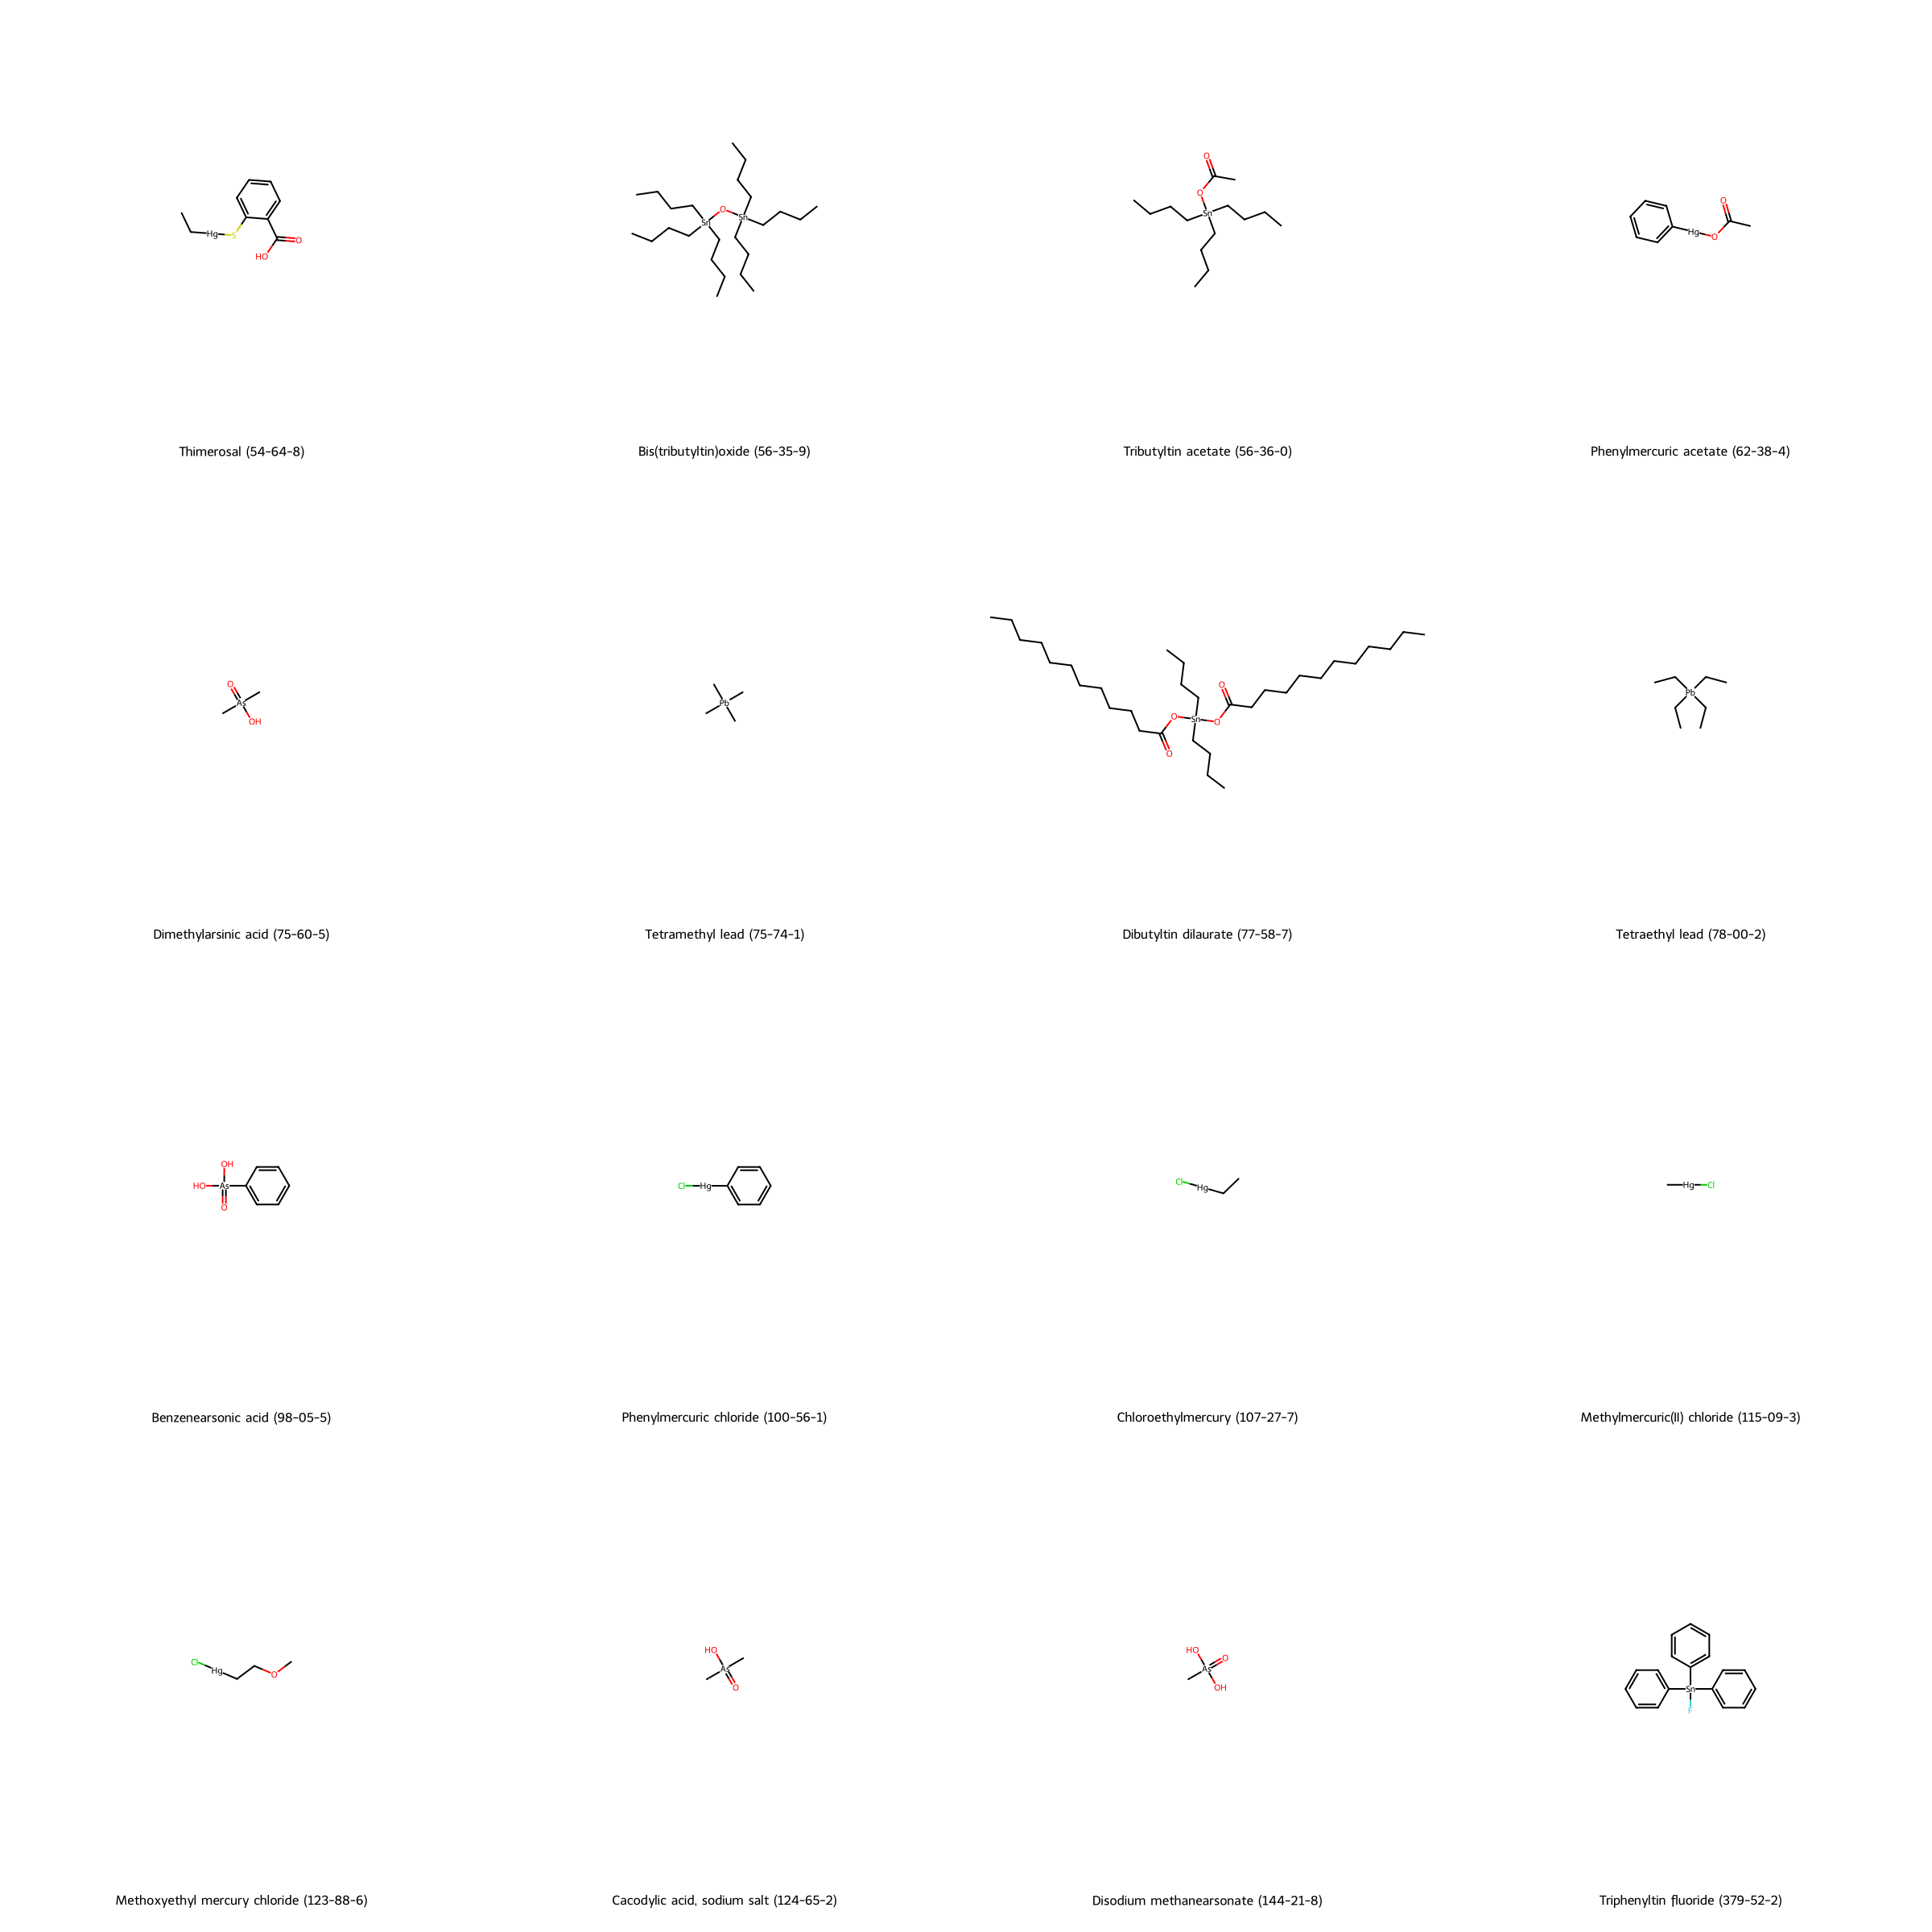

In [70]:
from rdkit.Chem import Descriptors, Draw

Draw.MolsToGridImage(df[df['inorganic']].head(16)['mol'], legends=[f"{row['Chemical_name']} ({row['CAS_str']})" for _, row in df[df['inorganic']].head(16).iterrows()], molsPerRow=4, subImgSize=(600, 600))   

In [71]:
df.shape

(2372, 129)

In [72]:
df[df['inorganic']].shape

(69, 129)

In [73]:
# ---- Remove the inorganic molecules ----

df_organic = df[~df['inorganic']].copy().reset_index(drop=True)
print(f'After removing inorganic: {len(df_organic)} molecules remaining')

After removing inorganic: 2303 molecules remaining


---
## 8. Generate final SMILES and save

In [74]:
# Write back the curated SMILES
df_organic['SMILES_curated'] = df_organic['mol'].apply(
    lambda m: Chem.MolToSmiles(m, canonical=True) if m is not None else None
)

# Drop the helper columns and the mol object
cols_to_drop = ['mol', 'inorganic_no_carbon', 'inorganic_heavy_atom', 'inorganic']
cols_present = [c for c in cols_to_drop if c in df_organic.columns]
df_out = df_organic.drop(columns=cols_present)

print(f'Final dataset shape: {df_out.shape}')
df_out.head()

Final dataset shape: (2303, 126)


,CAS_str,Chemical_name,log_LC50,n_measurements,SMILES,mlecule_H_final,SlogP,SMR,LabuteASA,TPSA,...,MQN34,MQN35,MQN36,MQN37,MQN38,MQN39,MQN40,MQN41,MQN42,SMILES_curated
0,50-06-6,Phenobarbital,2.685294,2,CCC1(C(=O)NC(=O)NC1=O)C2=CC=CC=C2,[H]c1c([H])c([H])c(C2(C([H])([H])C([H])([H])[H...,0.7004,60.0924,115.175275,75.27,...,0,0,2,0,0,0,0,0,0,CCC1(c2ccccc2)C(=O)NC(=O)NC1=O
1,50-18-0,Cyclophosphamide,3.340444,1,C1CNP(=O)(OC1)N(CCCl)CCCl,[H]N1C([H])([H])C([H])([H])C([H])([H])OP1(=O)N...,1.8840,59.1912,115.574149,41.57,...,0,0,1,0,0,0,0,0,0,O=P1(N(CCCl)CCCl)NCCCO1
2,50-28-2,17beta-Estradiol,0.330673,5,C[C@]12CC[C@H]3[C@H]([C@@H]1CC[C@@H]2O)CCC4=C3...,[H]Oc1c([H])c([H])c2c(c1[H])C([H])([H])C([H])(...,3.6092,78.7306,154.274315,40.46,...,0,1,3,0,0,0,0,6,3,C[C@]12CC[C@@H]3c4ccc(O)cc4CC[C@H]3[C@@H]1CC[C...
3,50-29-3,"p,p'-DDT",-1.737289,448,C1=CC(=CC=C1C(C2=CC=C(C=C2)Cl)C(Cl)(Cl)Cl)Cl,[H]c1c([H])c(C([H])(c2c([H])c([H])c(Cl)c([H])c...,6.4955,85.0370,149.379447,0.00,...,0,0,2,0,0,0,0,0,0,Clc1ccc(C(c2ccc(Cl)cc2)C(Cl)(Cl)Cl)cc1
4,50-30-6,"2,6-Dichlorobenzoic acid",2.112655,6,C1=CC(=C(C(=C1)Cl)C(=O)O)Cl,[H]OC(=O)c1c(Cl)c([H])c([H])c([H])c1Cl,2.6916,43.4213,79.065186,37.30,...,0,0,1,0,0,0,0,0,0,O=C(O)c1c(Cl)cccc1Cl


In [75]:
df_out.tail()

,CAS_str,Chemical_name,log_LC50,n_measurements,SMILES,mlecule_H_final,SlogP,SMR,LabuteASA,TPSA,...,MQN34,MQN35,MQN36,MQN37,MQN38,MQN39,MQN40,MQN41,MQN42,SMILES_curated
2298,874967-67-6,Sedaxane,-0.170091,4,CN1C=C(C(=N1)C(F)F)C(=O)NC2=CC=CC=C2C3CC3C4CC4,[H]c1c([H])c([H])c(C2([H])C([H])([H])C2([H])C2...,4.12350,86.1322,165.163499,46.92,...,0,1,1,0,0,0,0,0,0,Cn1cc(C(=O)Nc2ccccc2C2CC2C2CC2)c(C(F)F)n1
2299,907204-31-3,Fluxapyroxad,0.380211,1,CN1C=C(C(=N1)C(F)F)C(=O)NC2=CC=CC=C2C3=CC(=C(C...,[H]c1c([H])c([H])c(N([H])C(=O)c2c(C([H])(F)F)n...,4.69430,87.8702,166.704415,46.92,...,0,1,2,0,0,0,0,0,0,Cn1cc(C(=O)Nc2ccccc2-c2cc(F)c(F)c(F)c2)c(C(F)F)n1
2300,950782-86-2,Indaziflam,-0.283654,3,C[C@H]1CC2=C([C@@H]1NC3=NC(=NC(=N3)N)C(C)F)C=C...,[H]c1c([H])c2c(c([H])c1C([H])([H])[H])[C@]([H]...,3.13812,84.1731,157.025073,76.72,...,0,1,2,0,0,0,0,2,1,Cc1ccc2c(c1)[C@H](Nc1nc(N)nc(C(C)F)n1)[C@@H](C)C2
2301,1197379-16-0,"4-(1-Ethyl-1,3-dimethylpentyl)-2-nitrophenol",1.007160,3,CCC(C)CC(C)(CC)C1=CC(=C(C=C1)O)[N+](=O)[O-],[H]Oc1c([H])c([H])c(C(C([H])([H])[H])(C([H])([...,4.40430,76.4762,146.564083,63.37,...,0,0,1,0,0,0,0,0,0,CCC(C)CC(C)(CC)c1ccc(O)c([N+](=O)[O-])c1
2302,1197379-18-2,"2-Bromo-4-(1-ethyl-1,3-dimethylpentyl)phenol",1.207767,3,CCC(C)CC(C)(CC)C1=CC(=C(C=C1)O)Br,[H]Oc1c([H])c([H])c(C(C([H])([H])[H])(C([H])([...,5.25860,77.5218,145.778655,20.23,...,0,0,1,0,0,0,0,0,0,CCC(C)CC(C)(CC)c1ccc(O)c(Br)c1


In [76]:
ddf_testr = df_out.groupby('SMILES_curated').agg(
    CAS=('CAS_str', 'first'),
    logC50=('log_LC50', 'median'),
    n_measurements=('CAS_str', 'count')).reset_index()

In [77]:
proeblematic_mol = Chem.MolFromSmiles('O=C(O)COc1ccc(Cl)cc1Cl')

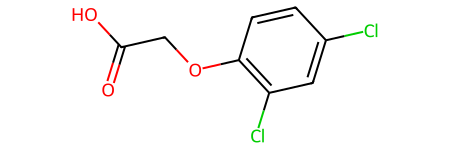

In [78]:
proeblematic_mol

In [79]:
df_organic[df_organic["SMILES_curated"] == 'CC(=O)O']

,CAS_str,Chemical_name,log_LC50,n_measurements,SMILES,mlecule_H_final,SlogP,SMR,LabuteASA,TPSA,...,MQN38,MQN39,MQN40,MQN41,MQN42,mol,inorganic_no_carbon,inorganic_heavy_atom,inorganic,SMILES_curated


In [80]:
ddf_testr.sort_values(by='n_measurements', ascending=False).head(10)

,SMILES_curated,CAS,logC50,n_measurements
1748,O=C(O)COc1ccc(Cl)cc1Cl,94-75-7,2.233714,10
1739,O=C(O)CN(CCN(CC(=O)O)CC(=O)O)CC(=O)O,60-00-4,3.038408,5
968,CN(C)C(=S)S,128-03-0,-0.569140,5
1451,ClC1C(Cl)C(Cl)C(Cl)C(Cl)C1Cl,58-89-9,0.052883,5
2078,S=C(S)NCCNC(=S)S,142-59-6,0.608467,4
2023,Oc1c(Cl)c(Cl)c(Cl)c(Cl)c1Cl,87-86-5,-0.775277,4
1738,O=C(O)CN(CC(=O)O)CC(=O)O,139-13-9,2.581117,4
1869,O=S(=O)(O)C(F)(F)C(F)(F)C(F)(F)C(F)(F)C(F)(F)C...,1763-23-1,1.255465,4
1167,COc1c(Cl)ccc(Cl)c1C(=O)O,1918-00-9,2.197741,4
1743,O=C(O)CNCP(=O)(O)O,1071-83-6,1.547074,4


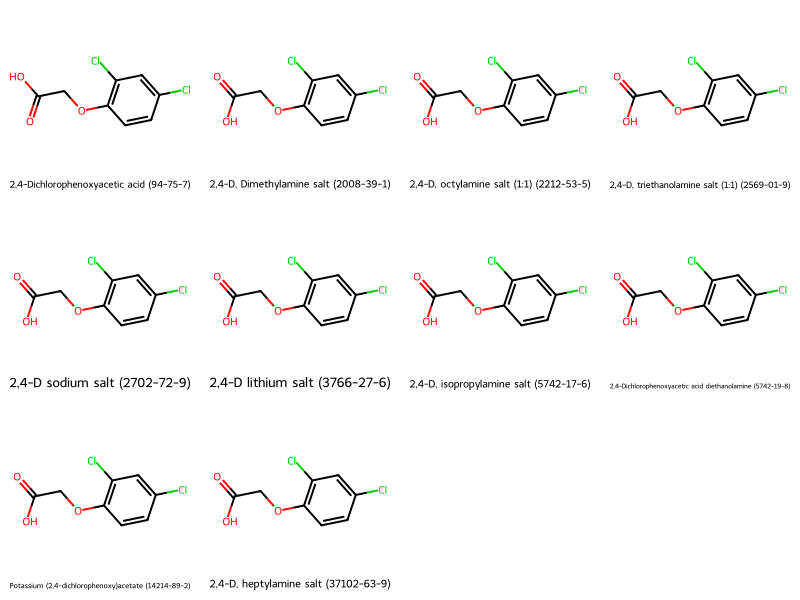

In [81]:
Draw.MolsToGridImage(df_organic[df_organic["SMILES_curated"] == 'O=C(O)COc1ccc(Cl)cc1Cl']['mol'], legends=[f"{row['Chemical_name']} ({row['CAS_str']})" for _, row in df_organic[df_organic["SMILES_curated"] == 'O=C(O)COc1ccc(Cl)cc1Cl'].iterrows()], molsPerRow=4)   

## Calculate the median logLC50 for each unique molecule and save the curated dataset.

In [82]:
df_out = df_out.groupby('SMILES_curated').agg(
    CAS=('CAS_str', 'first'),
    logC50=('log_LC50', 'median'),
    n_measurements=('log_LC50', 'count')
).reset_index()

In [83]:
df_out.shape

(2146, 4)

In [84]:
output_path = 'data/curated_data_rdkit_Abdou.csv'
# output_path = 'data/curated_data_rdkit_Imane.csv' 
df_out.to_csv(output_path, index=False)
print(f'Saved to {output_path}')

Saved to data/curated_data_rdkit_Abdou.csv


In [85]:
# Quick summary
print('--- Summary ---')
print(f'Original rows:                     2375')
print(f'After dropping missing SMILES:     {len(df)}')
print(f'After removing inorganic:          {len(df_organic)}')
print(f'Dropped (inorganic):               {n_inorganic}')
print(f'Final columns:                     {list(df_out.columns)}')

--- Summary ---
Original rows:                     2375
After dropping missing SMILES:     2372
After removing inorganic:          2303
Dropped (inorganic):               69
Final columns:                     ['SMILES_curated', 'CAS', 'logC50', 'n_measurements']
